## Imports

In [2]:
# Importing the 'os' module to interact with the operating system
# (used for file paths, environment variables, directory operations, etc.)
import os

# Importing dotenv to load environment variables from a .env file
# Useful for storing API keys or configuration values securely.
import dotenv

# Importing commonly used data and visualization libraries:
# pandas → For data loading, cleaning, and analysis.
# numpy → For numerical computations and array operations.
# seaborn → For statistical data visualization.
# matplotlib.pyplot → For creating plots and charts manually.
# warnings → To control or suppress warning messages during execution.
import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt, warnings

# Importing train_test_split to divide the dataset into training and testing sets.
# Importing cross_val_score for cross-validation to evaluate model stability.
from sklearn.model_selection import train_test_split, cross_val_score

# ColumnTransformer allows applying different preprocessing steps
# to numerical and categorical columns separately.
from sklearn.compose import ColumnTransformer

# OneHotEncoder converts categorical variables into numerical form
# using one-hot encoding (creating dummy variables).
from sklearn.preprocessing import OneHotEncoder

# SimpleImputer helps fill missing values (e.g., replace NaN with mean, median, or most frequent value).
from sklearn.impute import SimpleImputer

# Pipeline lets us chain preprocessing steps and the model into one unified workflow,
# ensuring consistent transformations during training and prediction.
from sklearn.pipeline import Pipeline

# Importing various tools for building and visualizing a Decision Tree model:
# DecisionTreeClassifier → The machine learning model used for prediction.
# plot_tree → To visualize the structure of the decision tree.
# _tree and export_text → To extract and print the rules of the trained tree.
from sklearn.tree import DecisionTreeClassifier, plot_tree, _tree, export_text

# Importing common evaluation metrics:
# accuracy_score → Measures overall model accuracy.
# classification_report → Shows precision, recall, F1-score for each class.
# confusion_matrix → Displays correct vs incorrect predictions.
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Suppressing warnings to keep the notebook output clean
warnings.filterwarnings("ignore")



## Load Dataset

In [4]:
# Load all environment variables from the .env file into the notebook session.
# This allows us to keep file paths and sensitive values outside the code.
dotenv.load_dotenv()

# Retrieve the dataset directory path from the environment variables.
# Using environment variables makes the notebook portable and avoids hard-coding paths.
dataset_path = os.getenv('DATASET_PATH')

# Read the loan dataset CSV file into a pandas DataFrame.
# os.path.join ensures the path works on all operating systems.
df = pd.read_csv(os.path.join(dataset_path, "loan_dataset.csv"))

# Remove the 'Loan_ID' column from the dataset.
# This ID is just a unique identifier and does not help in prediction,
# so keeping it would add noise and worsen model performance.
df = df.drop(columns=['Loan_ID'])  # ACTUAL DROP

# Create the feature matrix (X) by dropping the target column 'Loan_Status'.
# X will contain all the input variables used for prediction.
X = df.drop('Loan_Status', axis=1)

# Convert the 'Loan_Status' values from strings ('Y'/'N') into binary numbers (1/0).
# This numerical format is required for machine learning algorithms.
y = df.Loan_Status.map({'Y':1,'N':0})  # string → binary

# Split the dataset into training and testing sets.
# test_size=0.20 → 20% of the data is used for testing.
# random_state=42 → ensures reproducible results.
# stratify=y → keeps the same proportion of approved/rejected loans in both sets,
# which prevents biased splits when the target classes are imbalanced.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


## Preprocessing Pipelines

In [5]:
# Define the list of numerical columns.
# These are continuous or integer-valued features, so they will receive numeric imputations.
num_cols = ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term', 'Credit_History']

# Define the list of categorical columns.
# These contain non-numeric labels and will need encoding before feeding into the model.
cat_cols = ['Gender','Married','Dependents','Education','Self_Employed','Property_Area']

# Note: 'Credit_History' is already a 0/1 numeric indicator,
# so it correctly belongs in the numerical group.

# -----------------------------
# Build the preprocessing steps
# -----------------------------

# Create a pipeline for numeric columns.
# Step 1: Impute missing numeric values using the *median*,
# because median is resistant to outliers (e.g., extremely large incomes).
numeric_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='median'))  # median robust to outliers
])

# Create a pipeline for categorical columns.
# Step 1: Replace missing categories using the most frequent value (mode).
# Step 2: Convert categorical text labels into numerical vectors using one-hot encoding.
# 'handle_unknown="ignore"' ensures the model won't break if a new category appears in test data.
categoric_pipe = Pipeline(steps=[
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine the numeric and categorical pipelines into a single preprocessing transformer.
# ColumnTransformer applies the correct pipeline to the correct group of columns.
# This ensures consistent preprocessing during training and prediction.
preprocess = ColumnTransformer(
    transformers=[
        ('num', numeric_pipe, num_cols),  # apply numeric pipeline to numeric columns
        ('cat', categoric_pipe, cat_cols) # apply categorical pipeline to categorical columns
    ])



## Model Creation

In [6]:
# Create a Decision Tree classifier with controlled complexity.
# max_depth=5 → limits how deep the tree can grow to prevent overfitting.
# min_samples_split=50 → a node must have at least 50 samples before splitting;
#                        this stops the model from making overly specific splits.
# min_samples_leaf=25 → each leaf node must contain at least 25 samples,
#                       preventing branches based on very small groups.
# class_weight='balanced' → automatically adjusts weights for "Y" and "N"
#                           so the model does not favor the majority class.
# random_state=42 → ensures reproducible training results.
tree_clf = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=50,
    min_samples_leaf=25,
    class_weight='balanced',
    random_state=42
)

# Build a single pipeline that first preprocesses the data and then trains the model.
# ('prep', preprocess) → applies missing-value imputation + one-hot encoding.
# ('clf', tree_clf) → fits the Decision Tree on the transformed data.
# Using a pipeline ensures consistent preprocessing during training AND prediction.
model = Pipeline(steps=[
    ('prep', preprocess),
    ('clf', tree_clf)
])


## Model Evaluation

In [8]:
# Define a reusable evaluation function that trains a pipeline model
# and prints multiple performance metrics for both hold-out data
# and cross-validation.
def evaluate(pipeline, X_tr, y_tr, X_te, y_te):

    # Train (fit) the model using the training data.
    # This step learns the patterns from X_tr → y_tr.
    pipeline.fit(X_tr, y_tr)

    # Predict the loan approval outcomes on the unseen test set.
    # These predictions are compared against actual labels to measure performance.
    preds_te = pipeline.predict(X_te)

    # Print the overall accuracy on the test set.
    # Accuracy = percentage of correct predictions.
    print('Hold-out accuracy: {:.3f}'.format(accuracy_score(y_te, preds_te)))

    # Print precision, recall, and F1-score for each class (Approved vs Not Approved).
    # This helps understand *how* the model performs, not just *how often* it is correct.
    print('\nClassification report:\n', classification_report(y_te, preds_te))

    # Display a confusion matrix showing counts of:
    # True Positives, True Negatives, False Positives, False Negatives.
    # Useful for detecting bias or imbalance in predictions.
    print('Confusion matrix:\n', confusion_matrix(y_te, preds_te))

    # Perform 5-fold cross-validation on training data.
    # This splits training data into 5 parts and tests the model on each part,
    # giving a more stable view of model performance than a single split.
    cv = cross_val_score(pipeline, X_tr, y_tr, cv=5, scoring='accuracy')

    # Show the mean accuracy and standard deviation across the 5 folds.
    print('5-fold CV accuracy: {:.3f} ± {:.3f}'.format(cv.mean(), cv.std()))


# Call the evaluation function to train the model and display all metrics.
evaluate(model, X_train, y_train, X_test, y_test)




Hold-out accuracy: 0.764

Classification report:
               precision    recall  f1-score   support

           0       0.60      0.68      0.64        38
           1       0.85      0.80      0.82        85

    accuracy                           0.76       123
   macro avg       0.73      0.74      0.73       123
weighted avg       0.77      0.76      0.77       123

Confusion matrix:
 [[26 12]
 [17 68]]
5-fold CV accuracy: 0.668 ± 0.090


## Decision Tree Visualization

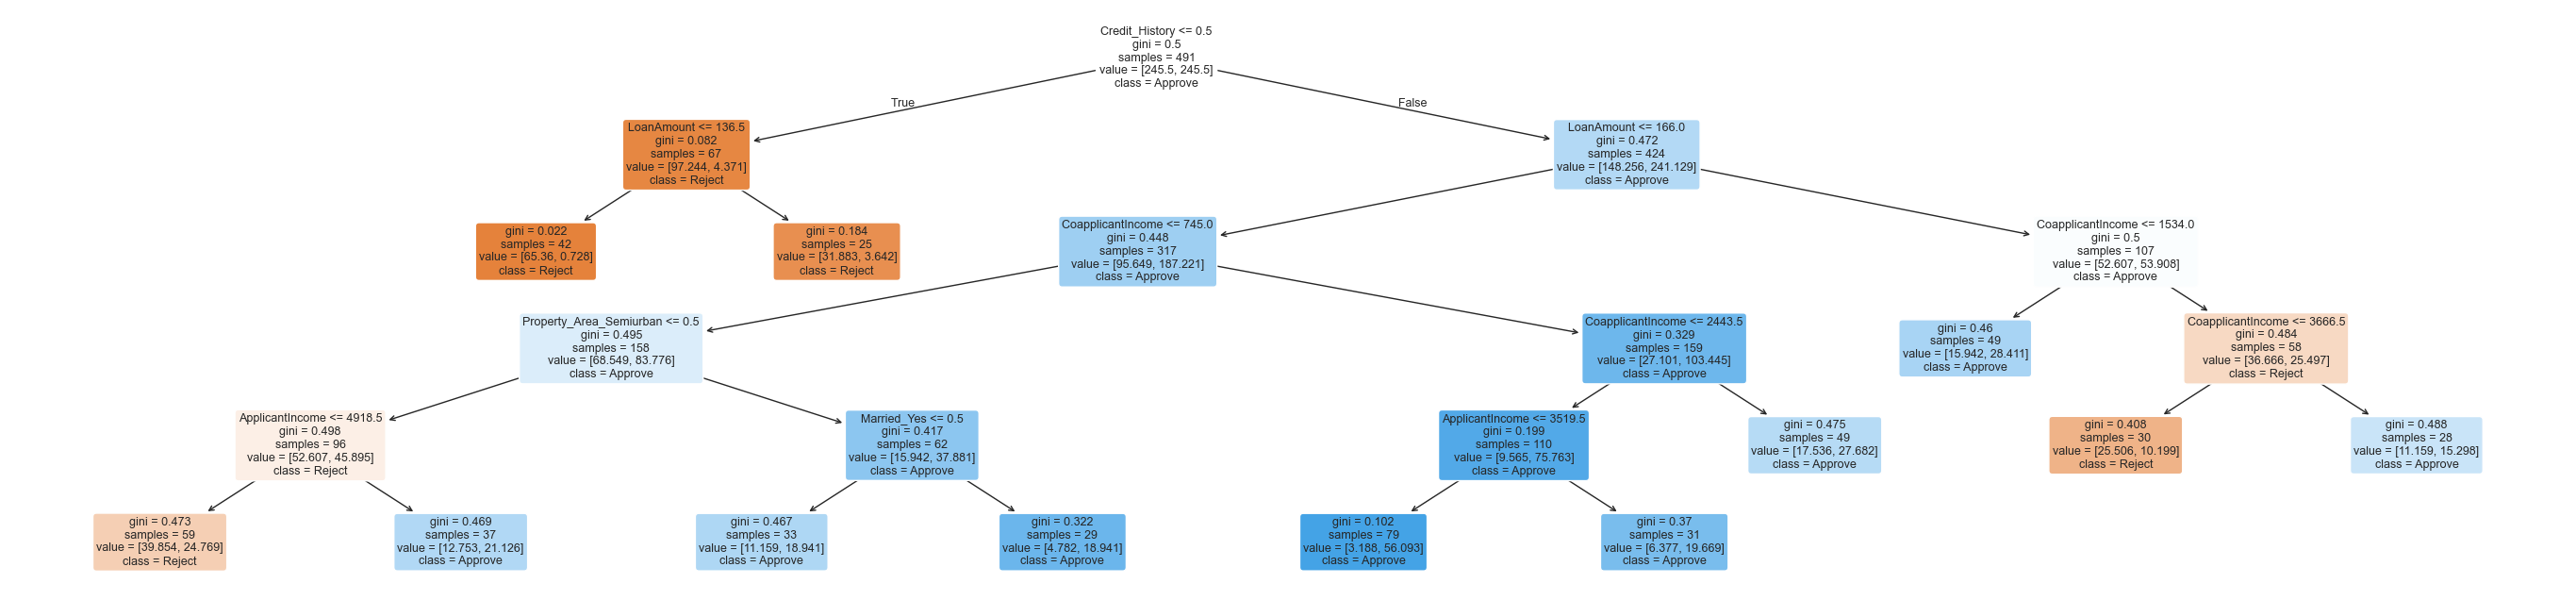

<Axes: xlabel='None', ylabel='None'>

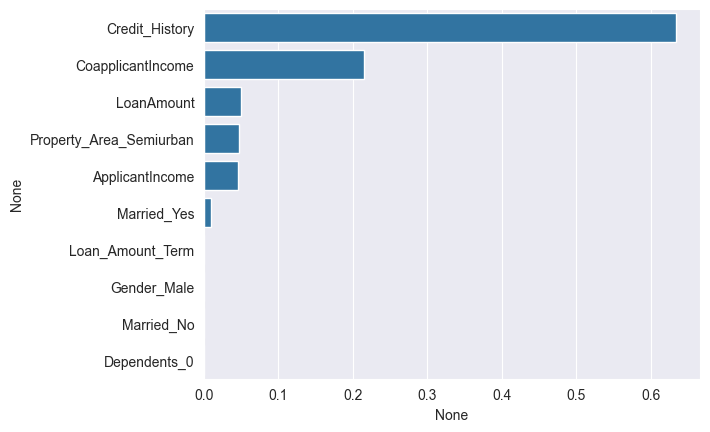

In [14]:
# Create a very wide figure so the decision tree visualization is readable.
plt.figure(figsize=(35,8))

# Extract the trained Decision Tree model from inside the pipeline.
# The pipeline has two steps: ('prep', ...) and ('clf', ...).
# Here we access the 'clf' part, which is the actual DecisionTreeClassifier.
tr = model.named_steps['clf']

# Extract the OneHotEncoder object from the preprocessing pipeline.
# This is needed to obtain the final expanded categorical feature names
# after one-hot encoding (since each category becomes its own column).
ohe = model.named_steps['prep'].named_transformers_['cat'].named_steps['onehot']

# Get the list of expanded feature names for categorical variables.
# Example: Property_Area → ['Property_Area_Rural', 'Property_Area_Urban', ...]
cat_features = ohe.get_feature_names_out(cat_cols)

# Combine numeric feature names and expanded categorical feature names
# into a single list, in the exact order used by the model.
all_features = np.r_[num_cols, cat_features]

# Plot the trained decision tree.
# feature_names → labels each split with the correct column name.
# class_names → labels leaf nodes with human-friendly names.
# filled=True → nodes are shaded based on class.
# rounded=True → visual improvement.
# fontsize=9 → ensures text fits inside nodes.
plot_tree(
    tr,
    feature_names=all_features,
    class_names=['Reject','Approve'],
    filled=True,
    rounded=True,
    fontsize=9
)

# Display the decision tree plot.
plt.show()

# Calculate feature importance scores from the tree.
# Convert them into a pandas Series for easier viewing.
# Sort in descending order to show most important features at the top.
imp = pd.Series(tr.feature_importances_, index=all_features).sort_values(ascending=False)

# Plot the top 10 most important features using a horizontal bar chart.
sns.barplot(x=imp.head(10), y=imp.head(10).index)




## Make Prediction

In [21]:
# Create a dictionary representing a single new loan applicant.
# Each key corresponds to a feature used in training, and the values
# represent this customer's actual information.
new_customer = {
    'Gender': 'Female',
    'Married': 'No',
    'Dependents': '0',
    'Education': 'Graduate',
    'Self_Employed': 'No',
    'ApplicantIncome': 6500,
    'CoapplicantIncome': 0,
    'LoanAmount': 120,
    'Loan_Amount_Term': 360,
    'Credit_History': 1,   # 1 = good credit history, 0 = poor/no history
    'Property_Area': 'Urban'
}

# Convert the dictionary into a one-row DataFrame.
# The model expects input in tabular format with the same column names as training data.
X_new = pd.DataFrame([new_customer])

# ----------------------------
# 2. MAKE A PREDICTION
# ----------------------------

# Predict the final loan decision for the new customer.
# The model outputs either 1 (Approve) or 0 (Reject).
pred = model.predict(X_new)[0]

# Predict the probability of each class.
# Returns something like: [ P(Reject), P(Approve) ].
prob = model.predict_proba(X_new)[0]

# Print the prediction in a user-friendly way.
print('Prediction :', 'APPROVE' if pred else 'REJECT')

# Print the probability of rejection and approval formatted as percentages.
print('Probabilities : Reject={:.2%}  Approve={:.2%}'.format(*prob))



Prediction : APPROVE
Probabilities : Reject=37.64%  Approve=62.36%


## Decision Path

In [22]:
# ------------------------------
# 3. SHOW THE DECISION PATH
# ------------------------------
# This section reveals which nodes in the decision tree were visited
# when predicting the outcome for the new customer.
# It helps explain *why* the model made its decision.

# Extract the fitted Decision Tree model from the pipeline.
tree_model = model.named_steps['clf']

# Retrieve the final feature names after preprocessing.
# Categorical features expand into many one-hot columns, so this step collects them.
feature_names = (
    model.named_steps['prep']
         .named_transformers_['cat']
         .named_steps['onehot']
         .get_feature_names_out(cat_cols)
)

# Combine numeric feature names with expanded categorical names.
# This creates a complete list in the exact order used by the model.
feature_names = np.r_[num_cols, feature_names]

# ---- IMPORTANT STEP ----
# Preprocess the new sample using the same transformation pipeline.
# This ensures the data matches the structure the tree expects.
X_new_prepared = model.named_steps['prep'].transform(X_new)

# Get the path of nodes visited during prediction.
# decision_path() returns a sparse matrix indicating which nodes were used.
node_indicator = tree_model.decision_path(X_new_prepared)

# Identify the final leaf node where the sample ended up.
leaf_id = tree_model.apply(X_new_prepared)

print('\nDecision path:')

# Loop through all nodes that were visited during the prediction.
for node_id in node_indicator.indices:

    # Skip leaf nodes—only internal splits have a feature and threshold.
    if tree_model.tree_.feature[node_id] != _tree.TREE_UNDEFINED:

        # Get the feature used at this split.
        feat = feature_names[tree_model.tree_.feature[node_id]]

        # Get the threshold value at this split.
        threshold = tree_model.tree_.threshold[node_id]

        # Determine whether the new customer's value goes left (<=) or right (>).
        sign = "<=" if X_new_prepared[0, tree_model.tree_.feature[node_id]] <= threshold else ">"

        # Print a readable explanation of the split.
        print(f"  node {node_id}:  {feat} {sign} {threshold:.3f}")

# Print which leaf was reached and the predicted class.
print(f"=> reached leaf {leaf_id[0]} → class {pred}")



Decision path:
  node 0:  Credit_History > 0.500
  node 4:  LoanAmount <= 166.000
  node 5:  CoapplicantIncome <= 745.000
  node 6:  Property_Area_Semiurban <= 0.500
  node 7:  ApplicantIncome > 4918.500
=> reached leaf 9 → class 1
